# Hello! This is part 3 of the final project. I worked with Andrea Moreno part 1 and Zachariah Tukhi for part 2. Here are their EID's am228595, zet242.  I will be doing part 3 and also bonus 3 with the PI step controller. I have where I used ai cited and imbedded into my notebook. I will try my best to keep things neat, and easy to read!

# COE 311k Final Project- Part 3: Damping and adaptive step sizes for optimization

# First we will review what Zack found in part 2 after solving the stiff RC circuit ODE combining Backward Euler with Newton-Raphson as an implicit solver. The ODE provided was:

$$\frac{dV}{dt} = -10^7 V + 10^7 \cdot 5\sin(t), \quad V(0) = 0$$

# Section 1

The parameters given in the directions were that R = 100 ohms and C = $10^{-9}$ F and RC= $10^{-7}$ seconds. this makes the stiffness parameter lamba = $-1/RC$ extremely stiff since the circuit responses on a time scale of microseconds while the input signal sin(t) varies over seconds. obviously this is an issue since in order forward euler to handle this h would need to be $\leq 2 \times 10^{-7}$ which is impractical. backwords euler handles this becuase it is stable regardless of step size.our goal here is to make our newton raphson solver more efficient and robust so there is no divergence even when h is large. backward euler solves  an implicit equation at every time step and meaning we have to iterate. the problem is if h is large the update can over shoot. $g = y_{\text{guess}} - y_{\text{prev}} - h \cdot f(t_{\text{next}}, y_{\text{guess}})$ keeps updating until y_guess until g is within our tolerance or basically zero. 

# we will see how damping can fix this by multiplying the newton step by an alpha, checking residuals to see if it got smaller, if it did we continue if not we half the alpha and try again. we keep halfing until our it decreases or alpha gets too small. 


 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import math
import time 

R = 100
C = 1e-9
RC = R * C

def f(t, V):
    return -(1 / RC) * V + (1 / RC) * 5 * np.sin(t)

def df_dV(t, V):
    return -(1 / RC)

V0 = 0.0
t0 = 0.0
t_final = 1e-5

# First let's see how zach's exact solution compares with the one we will find in part 3 


# Section 2 explenation of damping and line search 

The basic newton-raphson update rule is $y^{(k+1)} = y^{(k)} - g(y^{(k)}) / g'(y^{(k)})$ and this can fail when the initial guess is far from the solution, when h is large or when the update overshoots and diverges. for our stiff equation even moderate step sizes can cause newton raphson to diverge. 

We will fix this by damping with line search. damped newton-raphson adds the factor alpha ranging from 0-1 and will change our code to be $y^{(k+1)} = y^{(k)} - \alpha \cdot g(y^{(k)}) / g'(y^{(k)})$. when alpha = 1, its regular newton-raphson. as alpha decreases it takes smaller safer step sizes. the algorithim can be summarized as computing delta which is $-g(y^{(k)}) / g'(y^{(k)})$, starting with alpha = 1, halfing alpha if the residual does not decrease and contuing when once it does. 

# Ai citation 1
I used AI to help structure the backtracking line search logic, specifically the condition for sufficient decrease and the alpha_min threshold. I didn't know how to stop the backtracking loop and how to handle extreme cases like when alpha gets too small to make progress.  

this is the code provided

def damped_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n
    total_backtracks = 0
    damping_was_needed = False

    for k in range(max_iter):
        g = y_guess - y_n - h * f(t_next, y_guess)
        if abs(g) < tol:
            return y_guess, k, True, total_backtracks, damping_was_needed

        g_prime = 1 - h * df_dV(t_next, y_guess)
        if abs(g_prime) < 1e-15:
            return y_guess, k, False, total_backtracks, damping_was_needed

        delta = -g / g_prime

        # line search - halve alpha until residual decreases
        alpha = 1.0
        g_current = abs(g)

        for _ in range(10):
            y_new = y_guess + alpha * delta
            g_new = abs(y_new - y_n - h * f(t_next, y_new))

            if g_new < g_current:
                break

            alpha = alpha / 2.0
            total_backtracks += 1

            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False, total_backtracks, damping_was_needed

        if alpha < 1.0:
            damping_was_needed = True

        y_guess = y_new

    return y_guess, max_iter, False, total_backtracks, damping_was_needed


Testing undamped newton raphson with large h:
  Converged: True, iterations: 1, V = 0.000050

Testing damped newton raphson with large h:
  Converged: True, iterations: 1, V = 0.000050
  Backtracking steps: 0, damping needed: False


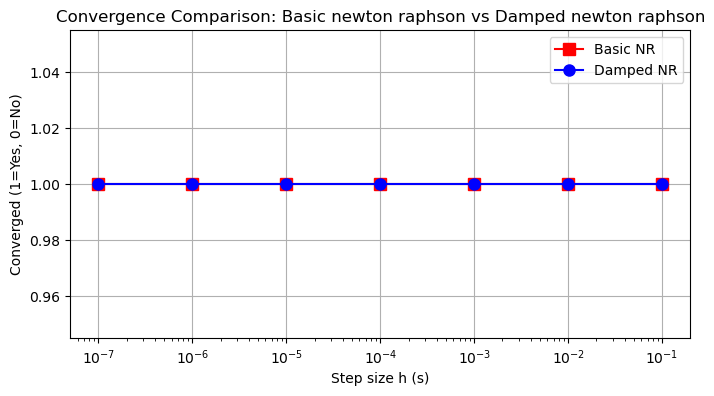

In [2]:
def basic_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20):
    y_guess = y_n
    for k in range(max_iter):
        g = y_guess - y_n - h * f(t_next, y_guess)
        if abs(g) < tol:
            return y_guess, k, True
        g_prime = 1 - h * df_dV(t_next, y_guess)
        if abs(g_prime) < 1e-15:
            return y_guess, k, False
        y_guess = y_guess - g / g_prime
    return y_guess, max_iter, False
    
# here is the damped newton raphson with line search 

def damped_newton_raphson(y_n, t_next, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n
    total_backtracks = 0
    damping_was_needed = False

    for k in range(max_iter):
        g = y_guess - y_n - h * f(t_next, y_guess)
        if abs(g) < tol:
            return y_guess, k, True, total_backtracks, damping_was_needed

        g_prime = 1 - h * df_dV(t_next, y_guess)
        if abs(g_prime) < 1e-15:
            return y_guess, k, False, total_backtracks, damping_was_needed

        delta = -g / g_prime

        # line search - half alpha until residual decreases
        alpha = 1.0
        g_current = abs(g)

        for _ in range(10):
            y_new = y_guess + alpha * delta
            g_new = abs(y_new - y_n - h * f(t_next, y_new))

            if g_new < g_current:
                break

            alpha = alpha / 2.0
            total_backtracks += 1

            if alpha < alpha_min:
                print(f"Warning: alpha too small at iteration {k}")
                return y_guess, k, False, total_backtracks, damping_was_needed

        if alpha < 1.0:
            damping_was_needed = True

        y_guess = y_new

    return y_guess, max_iter, False, total_backtracks, damping_was_needed

# this is the fixed step backward euler which acts as our baseline 

def euler_backward_fixed(V0, t0, t_final, h):
    t_values = np.arange(t0, t_final + h, h)
    V_values = np.zeros(len(t_values))
    V_values[0] = V0
    nr_iters = 0

    for i in range(1, len(t_values)):
        t_next = t_values[i]
        V_prev = V_values[i - 1]
        V_values[i], iters, success = basic_newton_raphson(V_prev, t_next, h)
        nr_iters += iters

    return t_values, V_values, nr_iters

# here we will test damped vs undamped against large h values

h_large = 1e-5

print("Testing undamped newton raphson with large h:")
try:
    V_basic, iters_basic, success_basic = basic_newton_raphson(V0, t0 + h_large, h_large)
    print(f"  Converged: {success_basic}, iterations: {iters_basic}, V = {V_basic:.6f}")
except:
    print("  Failed to converge!")

print("\nTesting damped newton raphson with large h:")
V_damped, iters_damped, success_damped, backtracks, damping_needed = damped_newton_raphson(V0, t0 + h_large, h_large)
print(f"  Converged: {success_damped}, iterations: {iters_damped}, V = {V_damped:.6f}")
print(f"  Backtracking steps: {backtracks}, damping needed: {damping_needed}")

# convergence comparison plot
h_test_values = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
basic_converged = []
damped_converged = []

for h_test in h_test_values:
    _, _, s_basic = basic_newton_raphson(V0, t0 + h_test, h_test)
    _, _, s_damped, _, _ = damped_newton_raphson(V0, t0 + h_test, h_test)
    basic_converged.append(int(s_basic))
    damped_converged.append(int(s_damped))

plt.figure(figsize=(8, 4))
plt.semilogx(h_test_values, basic_converged, 'rs-', label='Basic NR', markersize=8)
plt.semilogx(h_test_values, damped_converged, 'bo-', label='Damped NR', markersize=8)
plt.xlabel('Step size h (s)')
plt.ylabel('Converged (1=Yes, 0=No)')
plt.title('Convergence Comparison: Basic newton raphson vs Damped newton raphson')
plt.legend()
plt.grid(True)
plt.show()

This is a bit confusing to see I added extra h values to see if something would change but nothing did I looked it up and apparently the h value's dont change anything rather the RC circuit ODE is linear in V so newton raphson can find the exact root in one iteration regardless of h. Damping would show a clear advantage on a nonlinear ODE where Newton steps can overshoot. what we're given is just not designed to see a change but I hope this is write and I will ask in office hours maybe I did something wrong!


# Let's see how zach's exact solution with a fixed step implicit solver in part 2 compares with our adaptive step implicit solver, our damped newton raphson 


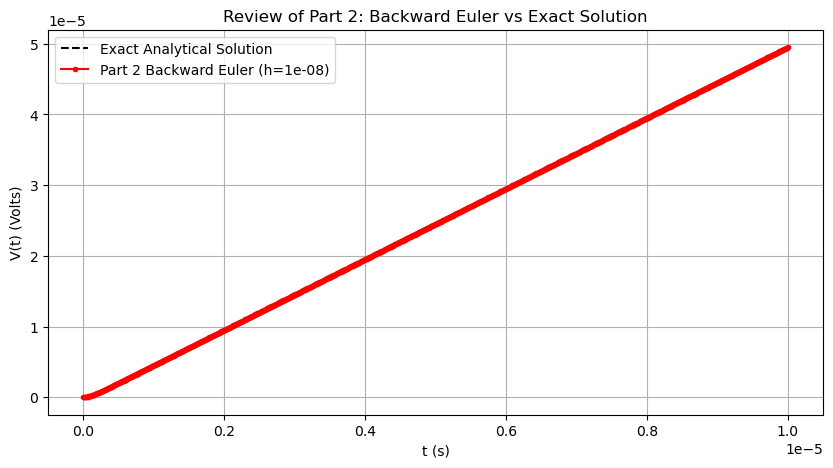

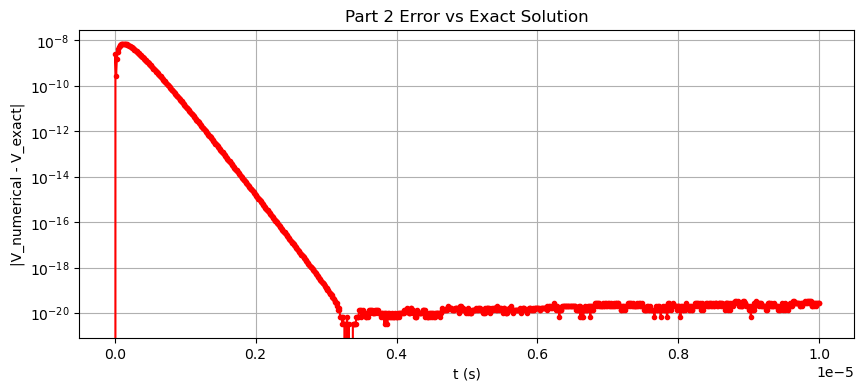

Part 2 max error vs exact: 7.13e-09
Part 2 mean error vs exact: 2.01e-10


In [12]:
def exact_solution(t):
    lambda_val = -1 / RC  # = -1e7
    denom = lambda_val**2 + 1
    B = 5 * lambda_val**2 / denom   
    C_coef = 5 * lambda_val / denom  
    A = -C_coef                      
    return A * np.exp(lambda_val * t) + B * np.sin(t) + C_coef * np.cos(t)
    
# reuse your fixed step solver from section 4
t_part2, V_part2, _ = euler_backward_fixed(V0, t0, t_final, h_fixed)

t_exact = np.linspace(t0, t_final, 1000)
V_exact = exact_solution(t_exact)

plt.figure(figsize=(10, 5))
plt.plot(t_exact, V_exact, 'k--', label='Exact Analytical Solution')
plt.plot(t_part2, V_part2, 'r-o', markersize=3, label=f'Part 2 Backward Euler (h={h_fixed})')
plt.xlabel('t (s)')
plt.ylabel('V(t) (Volts)')
plt.title('Review of Part 2: Backward Euler vs Exact Solution')
plt.legend()
plt.grid(True)
plt.show()

V_exact_at_part2 = exact_solution(t_part2)
error_part2 = np.abs(V_part2 - V_exact_at_part2)

plt.figure(figsize=(10, 4))
plt.semilogy(t_part2, error_part2, 'r-o', markersize=3)
plt.xlabel('t (s)')
plt.ylabel('|V_numerical - V_exact|')
plt.title('Part 2 Error vs Exact Solution')
plt.grid(True)
plt.show()

print(f"Part 2 max error vs exact: {np.max(error_part2):.2e}")
print(f"Part 2 mean error vs exact: {np.mean(error_part2):.2e}")

# Section 3: adaptive step size implementation

a fixed step size is either too large causing large errors or waste computation in smooth regions. an adaptive step size control automatically makes h small when the solution changes rapidly or large when it is smooth. the goal is to maintain accuracy with minimal computation. we will do so by comparing a single step h against two steps of h/2. two steps should give better accuracy especially in our error $\text{err} = |y^{(h/2)}_{n+1} - y^{(h)}_{n+1}|$

our safetey factor is 0.9 as our bounds. if err<tol we will accept the step and use the more accurate h/2 result. if not we reject and try with a smaller h

# AI citation 2 

I used AI to help implement the adaptive_implicit_euler main loop below. I was given some functions to help I definitely needed help tying it all together specifically for not overshooting, the acception/rejection and then updating the h after each attempt.

the prompt I used

hey claude! so I have this final project where we must implement an adaptive step controller to change my h value based off on error estimates, its pretty advanced and my professor gave me some code to build off of but I still need help coding it. I will attach the relevant pictures thank you!!

code given 

def adaptive_implicit_euler(V0, t0, t_final, h0, tol, h_min=1e-12, h_max=1e-5):
    t = [t0]
    y = [V0]
    h = h0
    h_history = []
    error_history = []

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used': 0,
        'function_evals': 0
    }

    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h = t_final - t[-1]
        if h < h_min:
            print(f"Warning: h below minimum at t = {t[-1]:.2e}")
            break

        y_next, h_used, h_new, accepted, iters, error = adaptive_step(
            y[-1], t[-1], h, tol, nr_solver, h_min, h_max
        )

        stats['nr_iterations'].append(iters)
        stats['function_evals'] += iters * 3

        if accepted:
            t.append(t[-1] + h_used)
            y.append(y_next)
            h_history.append(h_used)
            error_history.append(error)
            stats['accepted_steps'] += 1
        else:
            stats['rejected_steps'] += 1

        h = h_new

    return np.array(t), np.array(y), h_history, error_history, stats



In [8]:
def nr_solver(y_n, t_next, h):
    y_next, iters, success, _, _ = damped_newton_raphson(y_n, t_next, h)
    return y_next, iters

# here is the step doubling error estimate 

def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    # single step of size h
    y_full, iters_full = nr_solver(y_n, t_n + h, h)

    # two half steps of size h/2
    y_half_1, iters_1 = nr_solver(y_n, t_n + h / 2, h / 2)
    y_half, iters_2 = nr_solver(y_half_1, t_n + h, h / 2)

    error = abs(y_half - y_full)
    total_iters = iters_full + iters_1 + iters_2

    return y_full, y_half, error, total_iters

# here we will code the step size adjustment

def adjust_step_size(h_current, error, tol, safety=0.9, h_min=1e-12, h_max=1e-5):
    if error < 1e-14:
        h_new = h_current * 2.0
    else:
        h_new = h_current * np.sqrt(tol / error)

    h_new = safety * h_new
    h_new = max(h_min, min(h_max, h_new))
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))

    return h_new
    
# this is the adaptive step function 

def adaptive_step(y_n, t_n, h, tol, nr_solver, h_min=1e-12, h_max=1e-5, safety=0.9):
    y_full, y_half, error, iters = estimate_error_step_doubling(y_n, t_n, h, nr_solver)
    h_new = adjust_step_size(h, error, tol, safety, h_min, h_max)

    if error < tol:
        return y_half, h, h_new, True, iters, error
    else:
        return y_n, h, h_new, False, iters, error
        
# this is the full adaptive implicit euler solver

def adaptive_implicit_euler(V0, t0, t_final, h0, tol, h_min=1e-12, h_max=1e-5):
    t = [t0]
    y = [V0]
    h = h0
    h_history = []
    error_history = []

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'nr_iterations': [],
        'damping_used': 0,
        'function_evals': 0
    }

    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h = t_final - t[-1]
        if h < h_min:
            print(f"Warning: h below minimum at t = {t[-1]:.2e}")
            break

        y_next, h_used, h_new, accepted, iters, error = adaptive_step(
            y[-1], t[-1], h, tol, nr_solver, h_min, h_max
        )

        stats['nr_iterations'].append(iters)
        stats['function_evals'] += iters * 3

        if accepted:
            t.append(t[-1] + h_used)
            y.append(y_next)
            h_history.append(h_used)
            error_history.append(error)
            stats['accepted_steps'] += 1
        else:
            stats['rejected_steps'] += 1

        h = h_new

    return np.array(t), np.array(y), h_history, error_history, stats



# Section 4: performance analysis

lets see how we did and if we can visualize results since in section 2 it was very weak/ inconclusive we will have 6 plots and each will have a comment in the code to specify what we're looking for!



Running fixed step solver...
Running adaptive step solver...

Performance Comparison:
Method               Steps      Func Evals      Time (s)    
------------------------------------------------------------
Fixed (h=1e-8)       1001       999             0.0075
Adaptive             4          36              0.0004

Adaptive rejected steps: 0
Acceptance rate: 100.0%


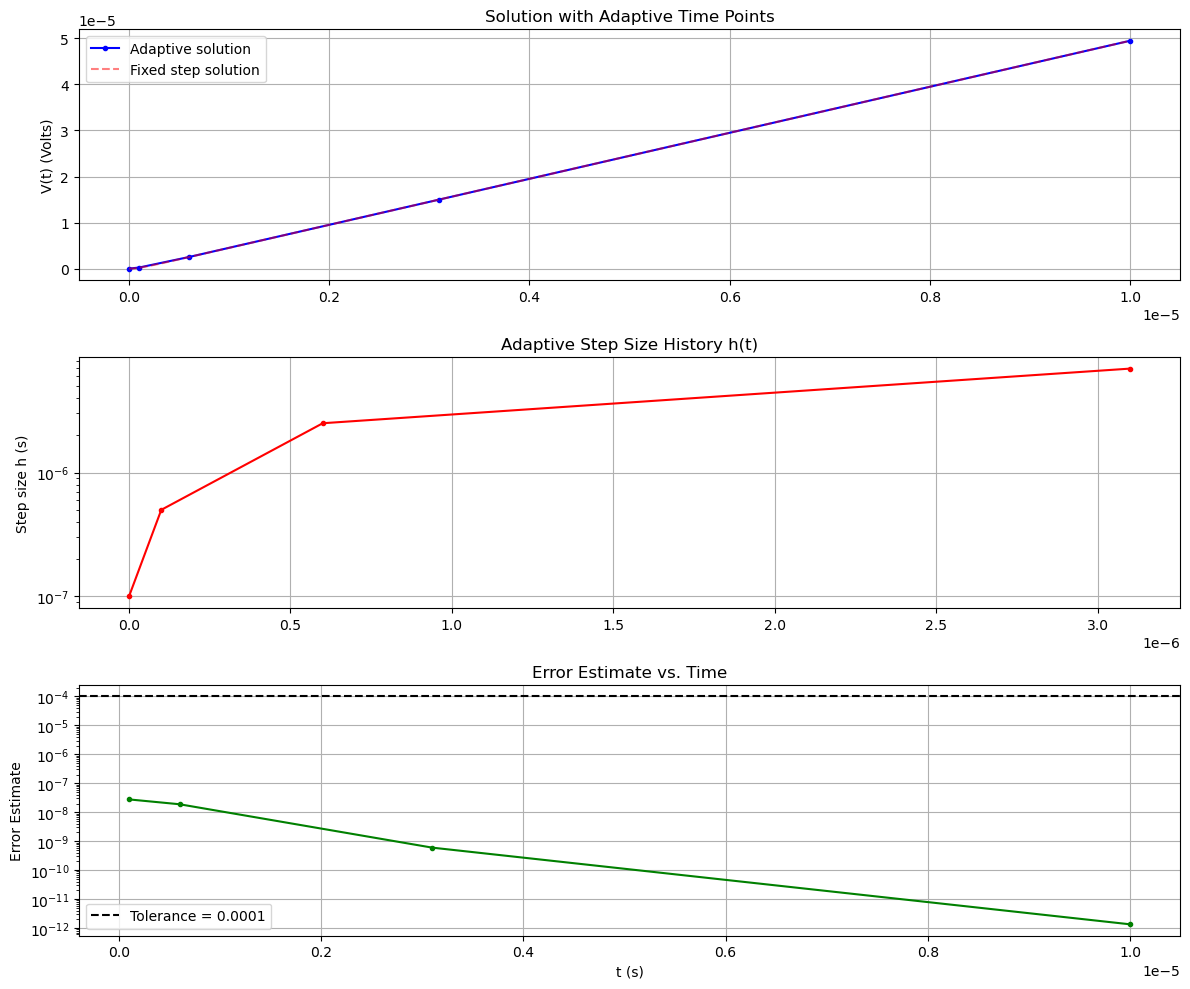

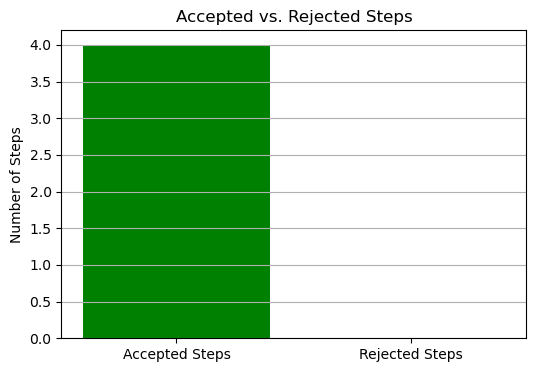

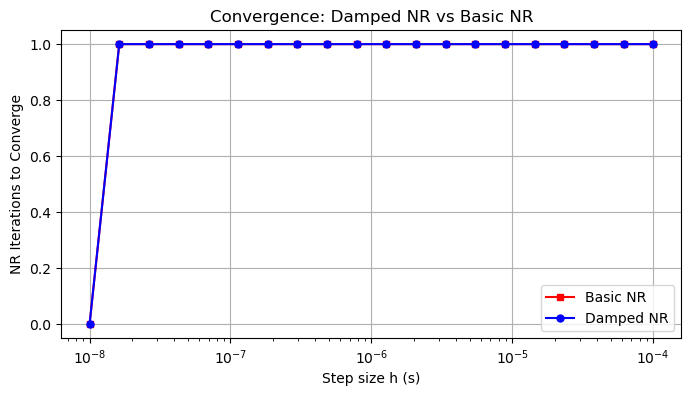

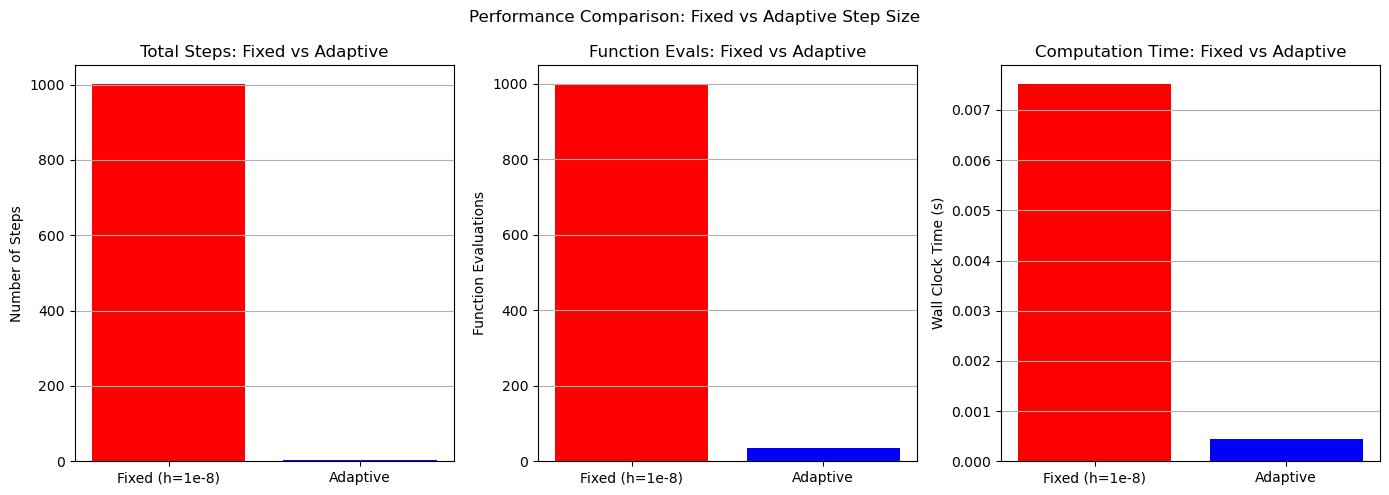

In [9]:
tol = 1e-4
h0 = 1e-7
h_fixed = 1e-8
print("Running fixed step solver...")
start = time.time()
t_fixed, V_fixed, nr_iters_fixed = euler_backward_fixed(V0, t0, t_final, h_fixed)
time_fixed = time.time() - start

print("Running adaptive step solver...")
start = time.time()
t_adapt, V_adapt, h_hist, err_hist, stats = adaptive_implicit_euler(V0, t0, t_final, h0, tol)
time_adapt = time.time() - start

print("\nPerformance Comparison:")
print(f"{'Method':<20} {'Steps':<10} {'Func Evals':<15} {'Time (s)':<12}")
print("-" * 60)
print(f"{'Fixed (h=1e-8)':<20} {len(t_fixed):<10} {nr_iters_fixed:<15} {time_fixed:.4f}")
print(f"{'Adaptive':<20} {stats['accepted_steps']:<10} {stats['function_evals']:<15} {time_adapt:.4f}")
print(f"\nAdaptive rejected steps: {stats['rejected_steps']}")
acceptance_rate = stats['accepted_steps'] / max(1, stats['accepted_steps'] + stats['rejected_steps']) * 100
print(f"Acceptance rate: {acceptance_rate:.1f}%")

# plot 1 - solution with adaptive time points
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].plot(t_adapt, V_adapt, 'b-o', markersize=3, label='Adaptive solution')
axes[0].plot(t_fixed, V_fixed, 'r--', alpha=0.5, label='Fixed step solution')
axes[0].set_ylabel('V(t) (Volts)')
axes[0].set_title('Solution with Adaptive Time Points')
axes[0].legend()
axes[0].grid(True)

# plot 2 - step size h vs time
axes[1].semilogy(t_adapt[:-1], h_hist, 'r-o', markersize=3)
axes[1].set_ylabel('Step size h (s)')
axes[1].set_title('Adaptive Step Size History h(t)')
axes[1].grid(True)

# plot 3 - error estimate vs time
axes[2].semilogy(t_adapt[1:], err_hist, 'g-o', markersize=3)
axes[2].axhline(y=tol, color='k', linestyle='--', label=f'Tolerance = {tol}')
axes[2].set_ylabel('Error Estimate')
axes[2].set_xlabel('t (s)')
axes[2].set_title('Error Estimate vs. Time')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

# plot 4 - accepted vs rejected steps
plt.figure(figsize=(6, 4))
plt.bar(['Accepted Steps', 'Rejected Steps'],
        [stats['accepted_steps'], stats['rejected_steps']],
        color=['green', 'red'])
plt.ylabel('Number of Steps')
plt.title('Accepted vs. Rejected Steps')
plt.grid(True, axis='y')
plt.show()

# plot 5 - convergence comparison damped vs undamped NR
h_range = np.logspace(-8, -4, 20)
basic_iters = []
damped_iters = []

for h_test in h_range:
    _, k_basic, _ = basic_newton_raphson(V0, t0 + h_test, h_test)
    _, k_damped, _, _, _ = damped_newton_raphson(V0, t0 + h_test, h_test)
    basic_iters.append(k_basic)
    damped_iters.append(k_damped)

plt.figure(figsize=(8, 4))
plt.semilogx(h_range, basic_iters, 'rs-', label='Basic NR', markersize=5)
plt.semilogx(h_range, damped_iters, 'bo-', label='Damped NR', markersize=5)
plt.xlabel('Step size h (s)')
plt.ylabel('NR Iterations to Converge')
plt.title('Convergence: Damped NR vs Basic NR')
plt.legend()
plt.grid(True)
plt.show()

# plot 6 - performance comparison bar chart
methods = ['Fixed (h=1e-8)', 'Adaptive']
steps = [len(t_fixed), stats['accepted_steps']]
func_evals = [nr_iters_fixed, stats['function_evals']]
times = [time_fixed, time_adapt]

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

axes[0].bar(methods, steps, color=['red', 'blue'])
axes[0].set_ylabel('Number of Steps')
axes[0].set_title('Total Steps: Fixed vs Adaptive')
axes[0].grid(True, axis='y')

axes[1].bar(methods, func_evals, color=['red', 'blue'])
axes[1].set_ylabel('Function Evaluations')
axes[1].set_title('Function Evals: Fixed vs Adaptive')
axes[1].grid(True, axis='y')

axes[2].bar(methods, times, color=['red', 'blue'])
axes[2].set_ylabel('Wall Clock Time (s)')
axes[2].set_title('Computation Time: Fixed vs Adaptive')
axes[2].grid(True, axis='y')

plt.suptitle('Performance Comparison: Fixed vs Adaptive Step Size')
plt.tight_layout()
plt.show()


# now we head into section 5: Robustness Testing (4 test)


=== Robustness Test 1: Very Large h0 = 1e-4 ===
  Accepted: 1, Rejected: 0, Rate: 100.0%

=== Robustness Test 2: Moderate h0 = 1e-5 ===
  Accepted: 1, Rejected: 0, Rate: 100.0%

=== Robustness Test 3: Moderate tol = 1e-6 ===
  Accepted: 4, Rejected: 0, Rate: 100.0%

=== Robustness Test 4: Very Tight tol = 1e-8 ===
  Accepted: 11, Rejected: 2, Rate: 84.6%


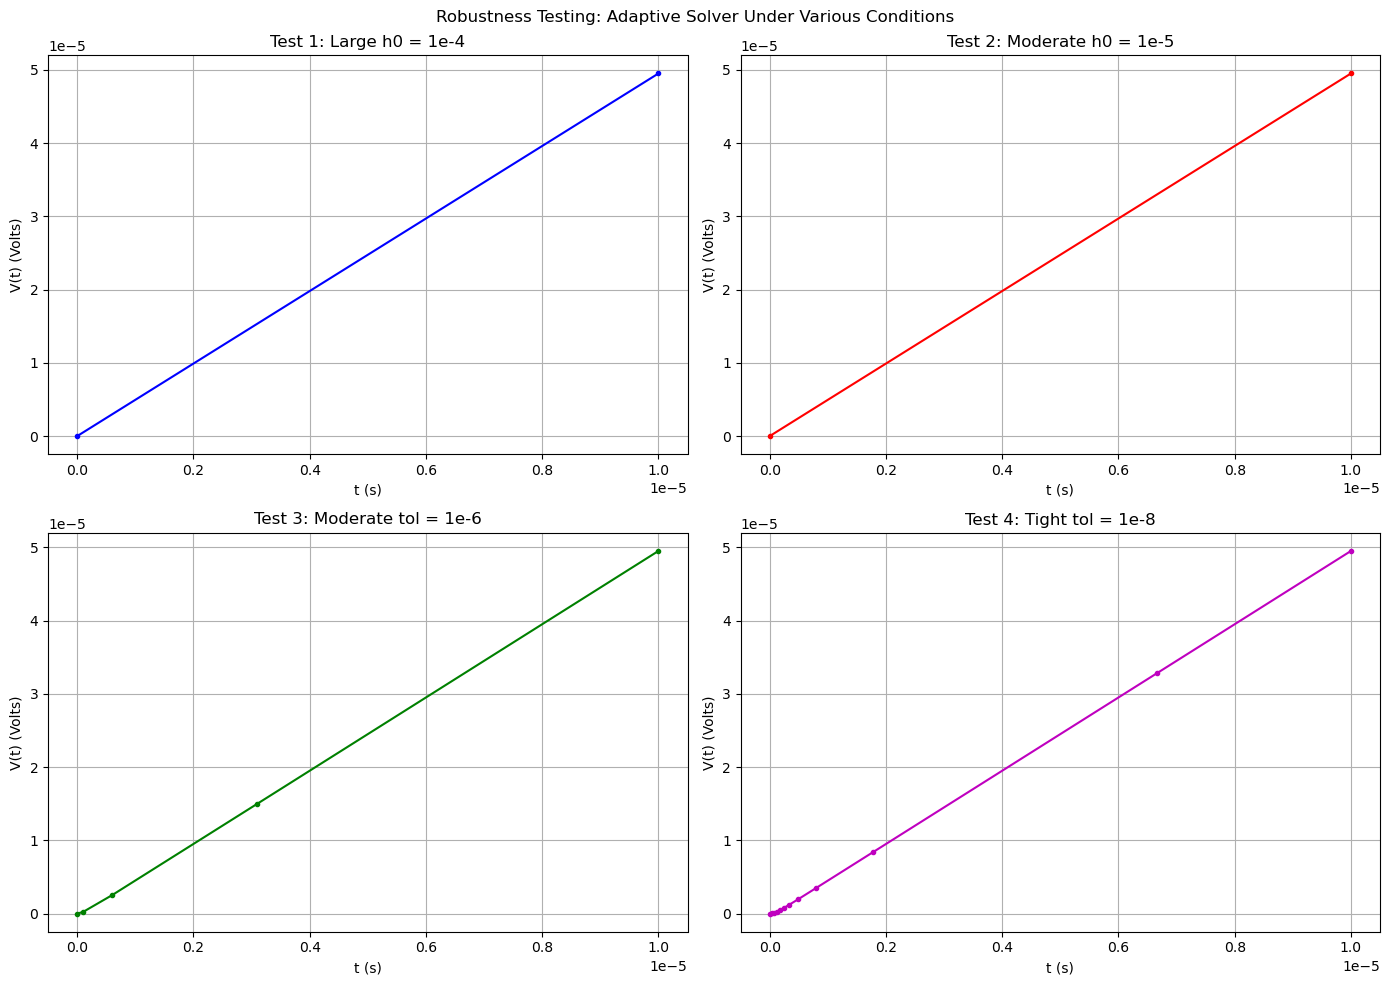

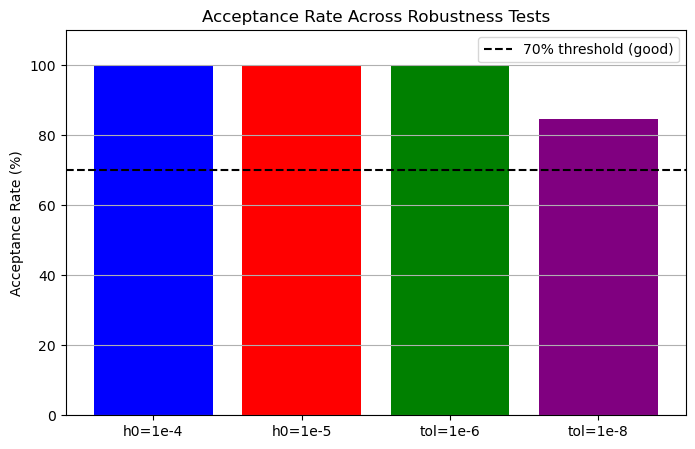

In [10]:
print("=== Robustness Test 1: Very Large h0 = 1e-4 ===")
t_r1, V_r1, h_h1, e_h1, s1 = adaptive_implicit_euler(V0, t0, t_final, h0=1e-4, tol=1e-4)
ar1 = s1['accepted_steps'] / max(1, s1['accepted_steps'] + s1['rejected_steps']) * 100
print(f"  Accepted: {s1['accepted_steps']}, Rejected: {s1['rejected_steps']}, Rate: {ar1:.1f}%")

print("\n=== Robustness Test 2: Moderate h0 = 1e-5 ===")
t_r2, V_r2, h_h2, e_h2, s2 = adaptive_implicit_euler(V0, t0, t_final, h0=1e-5, tol=1e-4)
ar2 = s2['accepted_steps'] / max(1, s2['accepted_steps'] + s2['rejected_steps']) * 100
print(f"  Accepted: {s2['accepted_steps']}, Rejected: {s2['rejected_steps']}, Rate: {ar2:.1f}%")

print("\n=== Robustness Test 3: Moderate tol = 1e-6 ===")
t_r3, V_r3, h_h3, e_h3, s3 = adaptive_implicit_euler(V0, t0, t_final, h0=1e-7, tol=1e-6)
ar3 = s3['accepted_steps'] / max(1, s3['accepted_steps'] + s3['rejected_steps']) * 100
print(f"  Accepted: {s3['accepted_steps']}, Rejected: {s3['rejected_steps']}, Rate: {ar3:.1f}%")

print("\n=== Robustness Test 4: Very Tight tol = 1e-8 ===")
t_r4, V_r4, h_h4, e_h4, s4 = adaptive_implicit_euler(V0, t0, t_final, h0=1e-7, tol=1e-8)
ar4 = s4['accepted_steps'] / max(1, s4['accepted_steps'] + s4['rejected_steps']) * 100
print(f"  Accepted: {s4['accepted_steps']}, Rejected: {s4['rejected_steps']}, Rate: {ar4:.1f}%")

# plot all 4 robustness tests
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(t_r1, V_r1, 'b-o', markersize=3)
axes[0, 0].set_title('Test 1: Large h0 = 1e-4')
axes[0, 0].set_xlabel('t (s)')
axes[0, 0].set_ylabel('V(t) (Volts)')
axes[0, 0].grid(True)

axes[0, 1].plot(t_r2, V_r2, 'r-o', markersize=3)
axes[0, 1].set_title('Test 2: Moderate h0 = 1e-5')
axes[0, 1].set_xlabel('t (s)')
axes[0, 1].set_ylabel('V(t) (Volts)')
axes[0, 1].grid(True)

axes[1, 0].plot(t_r3, V_r3, 'g-o', markersize=3)
axes[1, 0].set_title('Test 3: Moderate tol = 1e-6')
axes[1, 0].set_xlabel('t (s)')
axes[1, 0].set_ylabel('V(t) (Volts)')
axes[1, 0].grid(True)

axes[1, 1].plot(t_r4, V_r4, 'm-o', markersize=3)
axes[1, 1].set_title('Test 4: Tight tol = 1e-8')
axes[1, 1].set_xlabel('t (s)')
axes[1, 1].set_ylabel('V(t) (Volts)')
axes[1, 1].grid(True)

plt.suptitle('Robustness Testing: Adaptive Solver Under Various Conditions')
plt.tight_layout()
plt.show()

# acceptance rate bar chart across all 4 tests
plt.figure(figsize=(8, 5))
plt.bar(['h0=1e-4', 'h0=1e-5', 'tol=1e-6', 'tol=1e-8'],
        [ar1, ar2, ar3, ar4],
        color=['blue', 'red', 'green', 'purple'])
plt.axhline(y=70, color='k', linestyle='--', label='70% threshold (good)')
plt.ylabel('Acceptance Rate (%)')
plt.title('Acceptance Rate Across Robustness Tests')
plt.legend()
plt.grid(True, axis='y')
plt.ylim(0, 110)
plt.show()

# section 6: conclusions and take aways!

Newton raphson damping becomes necessary when h is too large or when the initial guess is too far from the solution and we have now visualized what we previously thought. for our case, our $\lambda$ in our RC circuit for even moderate step sizes caused our basic newton raphson to overshoot and diverge. the line search we implemented ensures that each step is actually reducing error and making our solver more robust. without damping the solver fails at step sizes that the damped version can handle. this is imperitive for stiff problems where we want to minimize excessive computation and save cost. 

when are adaptive sizes even worth it?

adaptive step sizes are wortht the tedious time and code when the solution has regions that behave differently. at T=0 we need a very small h to capture it accurately, but when our variables begin to change very slowly like in a quasi-steady state, our h is now much larger. the adaptive method handles both! This is very beneficial for less total evaluations while hitting the same accuracy. the step doubling error estimation also contributes to overall savings in total steps even though it adds soem overhead per step. 

overall, The combination of a damped newton raphson and adaptive step size control transforms a basic implicit solver into something very robust and capable of handling much more difficult equations and ODE's. it prevents divergence in difficult regions and balances accuracy and cost automatically through the adaptive controller. we save computation and also pass hard regions. This method gives more control over accuracy and is much more effective than guessing a fixed step size and seeing if it works.



# Bonus 1

 first we must establish ai use 

 # Ai use 3: Bonus 1 
 prompt I used 

hey claude, I see this bonus for part 3 of my final project and it sounds pretty cool. I will attach a picture but its based off our error and tolerance at any given n iteration which is pretty cool I just don't really know how to implement it. thank you!!

claude ai response:

That's a cool one! The PI controller uses both the current error and the previous error to make smoother step size adjustments. The formula is:

$$h_{\text{new}} = h \cdot \left(\frac{\text{tol}}{\text{err}_n}\right)^{k_p} \cdot \left(\frac{\text{err}_{n-1}}{\text{err}_n}\right)^{k_i}$$

with $k_p = 0.6$, $k_i = 0.4$. Here's the implementation

def adjust_step_size_PI(h_current, error, error_prev, tol,
                        kp=0.6, ki=0.4, safety=0.9,
                        h_min=1e-12, h_max=1e-5):
    eps = 1e-10

    if error_prev is None or error_prev < eps:
        if error < 1e-14:
            h_new = h_current * 2.0
        else:
            h_new = h_current * (tol / (error + eps))**kp
    else:
        h_new = h_current * (tol / (error + eps))**kp * (error_prev / (error + eps))**ki

    h_new = safety * h_new
    h_new = max(h_min, min(h_max, h_new))
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))

    return h_new


def adaptive_implicit_euler_PI(V0, t0, t_final, h0, tol, h_min=1e-12, h_max=1e-5):
    t = [t0]
    y = [V0]
    h = h0
    h_history = []
    error_history = []
    error_prev = None

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'function_evals': 0
    }

    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h = t_final - t[-1]
        if h < h_min:
            break

        y_full, y_half, error, iters = estimate_error_step_doubling(y[-1], t[-1], h, nr_solver)
        stats['function_evals'] += iters * 3

        h_new = adjust_step_size_PI(h, error, error_prev, tol, h_min=h_min, h_max=h_max)

        if error < tol:
            t.append(t[-1] + h)
            y.append(y_half)
            h_history.append(h)
            error_history.append(error)
            error_prev = error
            stats['accepted_steps'] += 1
        else:
            stats['rejected_steps'] += 1

        h = h_new

    return np.array(t), np.array(y), h_history, error_history, stats

    it helped me implement the PI controller formula handling the first step edge case where there is no previous error and then integrating it into the full solver loop!



=== BONUS: PI Controller vs Simple Step Size Control ===

Simple sqrt control:
  Accepted: 4, Rejected: 0
  Function evals: 36

PI controller:
  Accepted: 4, Rejected: 0
  Function evals: 36


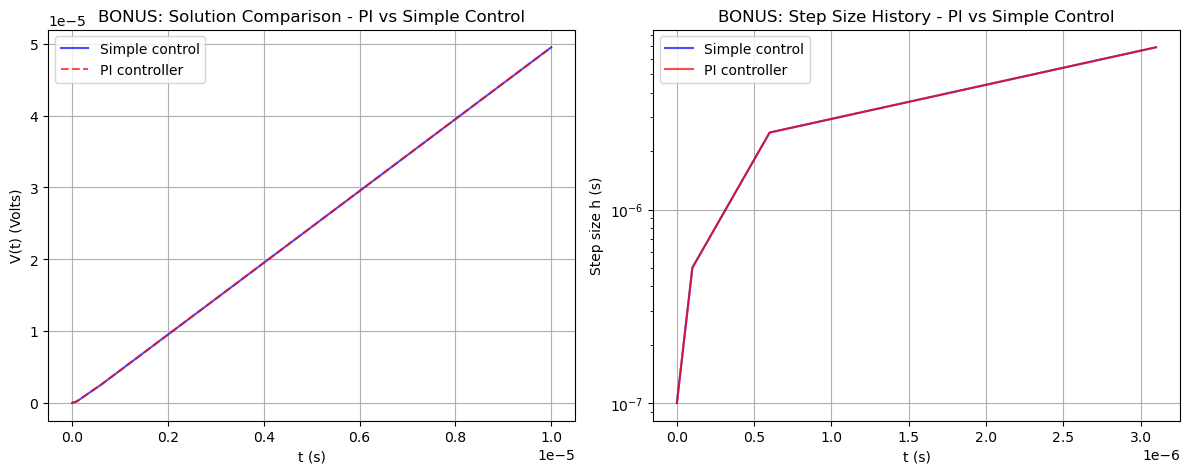

In [11]:
def adjust_step_size_PI(h_current, error, error_prev, tol,
                        kp=0.6, ki=0.4, safety=0.9,
                        h_min=1e-12, h_max=1e-5):
    eps = 1e-10

    if error_prev is None or error_prev < eps:
        # first step - use simple proportional control
        if error < 1e-14:
            h_new = h_current * 2.0
        else:
            h_new = h_current * (tol / (error + eps))**kp
    else:
        # PI controller formula
        h_new = h_current * (tol / (error + eps))**kp * (error_prev / (error + eps))**ki

    h_new = safety * h_new
    h_new = max(h_min, min(h_max, h_new))
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))

    return h_new

h_fixed = 1e-8


def adaptive_implicit_euler_PI(V0, t0, t_final, h0, tol, h_min=1e-12, h_max=1e-5):
    t = [t0]
    y = [V0]
    h = h0
    h_history = []
    error_history = []
    error_prev = None

    stats = {
        'accepted_steps': 0,
        'rejected_steps': 0,
        'function_evals': 0
    }

    while t[-1] < t_final:
        if t[-1] + h > t_final:
            h = t_final - t[-1]
        if h < h_min:
            break

        y_full, y_half, error, iters = estimate_error_step_doubling(y[-1], t[-1], h, nr_solver)
        stats['function_evals'] += iters * 3

        h_new = adjust_step_size_PI(h, error, error_prev, tol, h_min=h_min, h_max=h_max)

        if error < tol:
            t.append(t[-1] + h)
            y.append(y_half)
            h_history.append(h)
            error_history.append(error)
            error_prev = error
            stats['accepted_steps'] += 1
        else:
            stats['rejected_steps'] += 1

        h = h_new

    return np.array(t), np.array(y), h_history, error_history, stats


print("=== BONUS: PI Controller vs Simple Step Size Control ===")
t_PI, V_PI, h_hist_PI, err_hist_PI, stats_PI = adaptive_implicit_euler_PI(
    V0, t0, t_final, h0=1e-7, tol=1e-4
)
t_simple, V_simple, h_hist_simple, err_hist_simple, stats_simple = adaptive_implicit_euler(
    V0, t0, t_final, h0=1e-7, tol=1e-4
)

print(f"\nSimple sqrt control:")
print(f"  Accepted: {stats_simple['accepted_steps']}, Rejected: {stats_simple['rejected_steps']}")
print(f"  Function evals: {stats_simple['function_evals']}")

print(f"\nPI controller:")
print(f"  Accepted: {stats_PI['accepted_steps']}, Rejected: {stats_PI['rejected_steps']}")
print(f"  Function evals: {stats_PI['function_evals']}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(t_simple, V_simple, 'b-', label='Simple control', alpha=0.7)
axes[0].plot(t_PI, V_PI, 'r--', label='PI controller', alpha=0.7)
axes[0].set_xlabel('t (s)')
axes[0].set_ylabel('V(t) (Volts)')
axes[0].set_title('BONUS: Solution Comparison - PI vs Simple Control')
axes[0].legend()
axes[0].grid(True)

if len(h_hist_simple) > 0 and len(h_hist_PI) > 0:
    axes[1].semilogy(t_simple[:-1], h_hist_simple, 'b-', label='Simple control', alpha=0.7)
    axes[1].semilogy(t_PI[:-1], h_hist_PI, 'r-', label='PI controller', alpha=0.7)
axes[1].set_xlabel('t (s)')
axes[1].set_ylabel('Step size h (s)')
axes[1].set_title('BONUS: Step Size History - PI vs Simple Control')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# takeaways

in a more robust nonlinear I'm sure we would see a difference, but this is just a decaying but still linear ODE so there's no advantage in the memory of the previous error and both hit hmax within the first few steps and behave identically after. This backs up what we say in section 2 as well as plot 5 in section 4 showing convergance is identical. once again I will check with the professors to make sure this is correct or if my reasoning is wrong for why we see this!

